# Results of scMultiome

In [1]:
from deeptan.graph.model import DeepTAN
from deeptan.utils.uni import get_map_location

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



    ____                _________    _   __
   / __ \___  ___  ____/_  __/   |  / | / /
  / / / / _ \/ _ \/ __ \/ / / /| | /  |/ / 
 / /_/ /  __/  __/ /_/ / / / ___ |/ /|  /  
/_____/\___/\___/ .___/_/ /_/  |_/_/ |_/   
               /_/                         




## Read feature names

In [2]:
model_path="/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE235510_WT_strata/seed_42/DeepTAN_20250314171648_lzA6T/best-model-epoch=0018-val_loss=0.0000.ckpt"
model = DeepTAN.load_from_checkpoint(model_path, map_location=get_map_location())
# Freeze the model
model.eval()
model.freeze()

feature_names = model.all_node_names
print(f"{len(feature_names)} features in the model")
print(feature_names)
del model

5064 features in the model
['AT1G09210', 'AT1G25400', 'AT1G04820', 'AT1G69620', 'AT1G57860', 'AT1G56110', 'AT1G57660', 'AT1G04410', 'AT1G07790', 'AT1G27450', 'AT1G29470', 'AT1G06040', 'AT1G09640', 'AT1G26740', 'AT1G71170', 'AT1G75950', 'AT1G34430', 'AT1G49240', 'AT1G70850', 'AT1G74920', 'AT1G18080', 'AT1G09690', 'AT1G66200', 'AT1G20440', 'AT1G77750', 'AT1G52930', 'AT1G58270', 'AT1G23100', 'AT1G10590', 'AT1G09150', 'AT1G76680', 'AT1G27310', 'AT1G70780', 'AT1G18300', 'AT1G64750', 'AT1G63460', 'AT1G78040', 'AT1G36160', 'AT1G56660', 'AT1G30870', 'AT1G68440', 'AT1G67350', 'AT1G35720', 'AT1G74270', 'AT1G32460', 'AT1G66280', 'AT1G29850', 'AT1G31910', 'AT1G33120', 'AT1G51650', 'AT1G56330', 'AT1G18740', 'AT1G64230', 'AT1G48030', 'AT1G27330', 'AT1G07400', 'AT1G15040', 'AT1G75220', 'AT1G61790', 'AT1G07170', 'AT1G22780', 'AT1G29900', 'AT1G09780', 'AT1G80460', 'AT1G13730', 'AT1G15380', 'AT1G74030', 'AT1G23190', 'AT1G03850', 'AT1G69040', 'AT1G13390', 'AT1G01720', 'AT1G04480', 'AT1G43170', 'AT1G62975

## Read results

In [3]:
import pickle

In [4]:
path_pred = "/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE235510_WT_strata/seed_42/predicted_DeepTAN_20250314171648_lzA6T/seed_42_tst_numpy.pkl"

In [5]:
dict_pred = pickle.load(open(path_pred, "rb"))
print(dict_pred.keys())

dict_keys(['g_embedding', 'node_recon', 'node_recon_all', 'labels'])


/tmp/ipykernel_595979/193076933.py:1: ResourceWarning: unclosed file <_io.BufferedReader name='/mnt/hdd2/homext/wuch/xn2p/run/logs/GSE235510_WT_strata/seed_42/predicted_DeepTAN_20250314171648_lzA6T/seed_42_tst_numpy.pkl'>
  dict_pred = pickle.load(open(path_pred, "rb"))


### UMAP of cell embeddings

In [11]:
import numpy as np

In [6]:
cell_embedding = dict_pred["g_embedding"]
print(type(cell_embedding))
print(cell_embedding.shape)

<class 'numpy.ndarray'>
(564, 256)


In [12]:
cell_labels = dict_pred["labels"]
print(type(cell_labels))
print(cell_labels.shape)
# <class 'numpy.ndarray'>
# (564, 16)

# Apply argmax
cell_labels = np.argmax(cell_labels, axis=1)
print(cell_labels.shape)
# (564,)

<class 'numpy.ndarray'>
(564, 16)
(564,)


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import umap

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/umap/__init__.py:9: ImportWarning: Tensorflow not installed; ParametricUMAP will be unavailable
  warn(


In [14]:
reducer = umap.UMAP(n_components=2, random_state=42)
embedding_2d = reducer.fit_transform(cell_embedding)
print(embedding_2d.shape)

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(564, 2)


<Figure size 640x480 with 0 Axes>

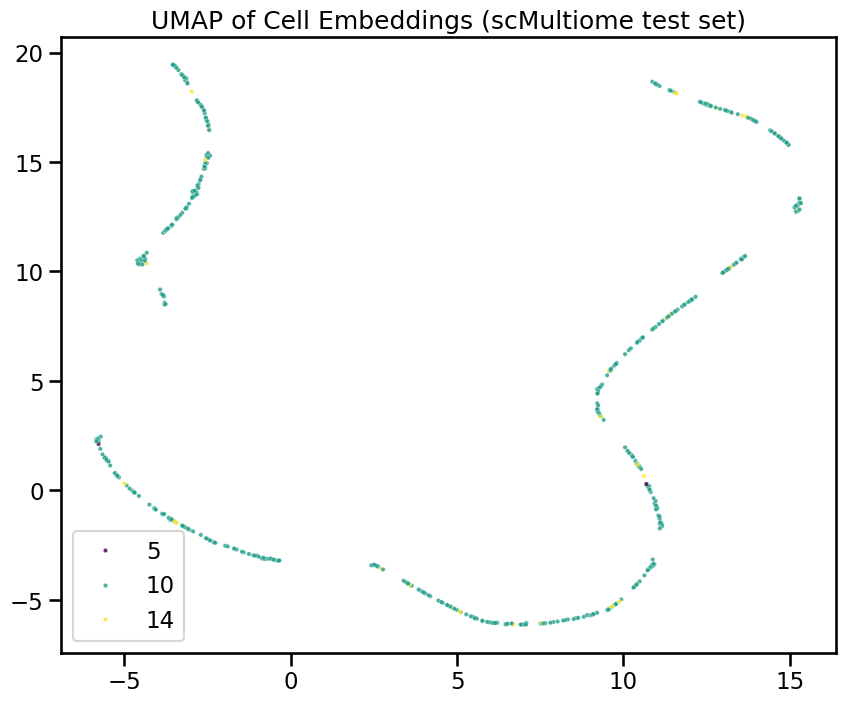

In [15]:
try:
    # Clear previous plots
    plt.clf()
except:
    pass
plt.figure(figsize=(10, 8))
sns.scatterplot(x=embedding_2d[:, 0], y=embedding_2d[:, 1], hue=cell_labels, palette="viridis", legend="full", s=10, alpha=0.8)
plt.title("UMAP of Cell Embeddings (scMultiome test set)")
plt.show()